# Hands-On Lab: K-Means Clustering
## Can an Algorithm Find Something Meaningful in Credit Card Data — Without Ever Being Told What Fraud Looks Like?

**Dataset:** `creditcard_45k.csv` — a 45,000-row subset of the Kaggle Credit Card Fraud Detection dataset

Each row is a transaction described by 28 anonymized PCA components (`V1`–`V28`), a `Time` field, a transaction `Amount`, and a `Class` label (0 = legitimate, 1 = fraud). 141 of the 45,000 transactions (about 0.31%) are fraudulent — still a heavily imbalanced dataset, just not quite as extreme as the full 284,807-row original (0.17% fraud there).

*Note: this run uses a smaller 45,000-row slice rather than the full dataset, which wasn't available to download this time. That difference in scope turns out to matter — see Step 5.*

## The Question This Lab Is Really Asking

K-Means is an **unsupervised** algorithm — it never sees a target label while it trains. So the question isn't "can we predict fraud?" (that's a supervised problem, solved elsewhere). The real question here is more honest and more interesting:

> *If we hide the `Class` label completely and just let K-Means look for structure in raw transaction behavior, what structure does it actually find — and does that structure turn out to say anything about fraud at all?*

That's the mystery this notebook works through, step by step. The label is brought back only once, at the very end, purely to check the answer against reality. Everything before that point is discovered blind — which mirrors a realistic business scenario: segment transactions by behavior first, then ask afterward whether that segmentation happens to be useful for something like fraud review.

## Tools Used
Scikit-learn (`KMeans`) • `StandardScaler` • Matplotlib • Jupyter Notebook


## Step 1 — First Question: What Has to Happen Before We Can Even Compare Two Transactions Fairly?

Before K-Means can group anything, every transaction needs to be described on equal footing. That raises two smaller questions.

**Which columns actually describe transaction *behavior*, and which don't?**
- `Class` is dropped. It's the ground-truth fraud label — keeping it, even indirectly, would secretly turn this into a supervised problem and defeat the entire point of the exercise.
- `Time` is dropped too. It only records *when* a transaction happened (seconds since the first row), not *what kind* of transaction it is. Feeding it to a distance-based algorithm would just add noise.

That leaves 29 numeric features: `V1`–`V28` and `Amount`.

**Are those 29 features already comparable to each other?**
No — and this matters more than it sounds. `Amount` ranges from 0 to tens of thousands of dollars, while the `V1`–`V28` components (already PCA-transformed) sit in a much smaller range. K-Means clusters purely on Euclidean distance, so without rescaling, `Amount` alone would dominate every distance calculation and the other 28 features would barely get a vote. `StandardScaler` fixes this by rescaling every feature to mean 0, standard deviation 1 — putting all 29 features on the same footing before the real question-asking begins.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("creditcard_45k.csv")
feature_cols = [c for c in df.columns if c not in ("Time", "Class")]
x = df[feature_cols].values
y_class = df["Class"].values
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print(f"Dataset shape: {df.shape}")
print(f"Features used for clustering: {feature_cols}")


Dataset shape: (45000, 31)
Features used for clustering: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


**A practical question first: do we still need a speed-motivated sample?**

Not this time. The earlier version of this lab worked with the full 284,807-row Kaggle file, where computing the elbow curve and silhouette score on every row would have been expensive - silhouette scoring compares every point against every other point, which scales quadratically. This version works from a 45,000-row subset instead (the full file wasn't available to download this time), which is small enough to run the elbow method and silhouette check **directly on the full scaled dataset**, with no separate sampling step required just to keep things fast.

`x_sample` below is simply an alias for `x_scaled` - kept so the rest of the notebook's structure doesn't change, and so it's obvious at a glance that no rows were held back.


In [2]:
rng = np.random.RandomState(42)
x_sample = x_scaled  # 45,000 rows total, small enough to use directly, no subsampling needed


## Step 2 — Next Question: How Many Natural Groups Does This Data Suggest?

K-Means requires the number of clusters, k, to be chosen in advance, and there's no single correct answer — it has to be inferred from the data itself. The elbow method asks the question experimentally: train a separate K-Means model for every k from 1 to 10, and record each model's **inertia** — the total squared distance between every point and the centroid it was assigned to.

Inertia always decreases as k grows (more clusters can only make points sit closer to their own centroid), so the goal isn't the lowest inertia — it's finding the point where adding more clusters stops buying a meaningful improvement. That turning point is the "elbow." Let's run the experiment and see what shape comes back.


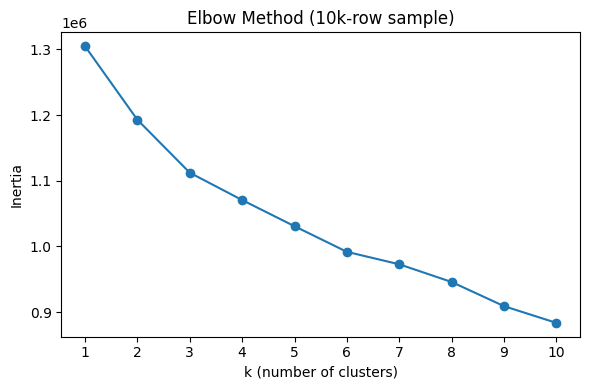

In [3]:
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_sample)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.title("Elbow Method (10k-row sample)")
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()


### What Does the Curve Answer?

The curve drops from k=1 to k=2 (about an 8.6% reduction in inertia), then keeps declining at a more gradual and slightly uneven pace all the way through k=10, without one clearly sharper bend standing out from the rest. Like the full-dataset version of this lab, there's no textbook elbow to read by eye.

Because the chart alone doesn't settle it, k=2 and k=3 — the two candidates around the steepest part of the curve — are carried forward to the silhouette check in Step 3 to decide quantitatively.


## Step 3 — Deciding Between the Two Suspects: k=2 or k=3?

The elbow chart narrowed things down but didn't settle the question, so a second, per-point measure is needed: the **silhouette score**. For every point, it compares the average distance to other points in its own cluster against the average distance to points in the nearest neighboring cluster, producing a score between -1 and +1. A higher average score means clusters are more clearly separated and more internally cohesive.

This is the step that actually decides between k=2 and k=3.


In [4]:
candidate_ks = [2, 3]
silhouette_scores = {}
for k in candidate_ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(x_sample)
    score = silhouette_score(x_sample, labels, sample_size=5000, random_state=42)
    silhouette_scores[k] = score
    print(f"k={k} -> silhouette score = {score:.3f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"Chosen k = {best_k}")


k=2 -> silhouette score = 0.803
k=3 -> silhouette score = 0.121
Chosen k = 2


### The Verdict

k=2 scores dramatically higher than k=3 (0.803 versus 0.121), so **k=2 is selected**. That 0.803 score is worth pausing on — it's much higher than the modest ~0.15 the full 284,807-row dataset produced. A silhouette score that close to +1 is the signature of one very tight, well-separated cluster sitting apart from a much larger, looser one, rather than two roughly comparable groups. That asymmetry is a preview of what Step 5 finds.


## Step 4 — Now That We Know k=2, What Do the Two Groups Actually Look Like?

With k=2 settled, the final K-Means model is trained on the full scaled dataset — all 45,000 transactions (no sampling was needed at any stage this time; see Step 1's note).

Since there are 29 features in total, they can't all be plotted at once, so two are picked for a 2D view: `Amount`, because it's directly interpretable, and `V14`, one of the PCA components most strongly associated with fraud patterns in this dataset. Because the full dataset is only 45,000 rows, every point is plotted — no readability subsample is needed this time. Let's look at the picture and see what it tells us.


In [5]:
final_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = final_km.fit_predict(x_scaled)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,cluster
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,1
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,1
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,1


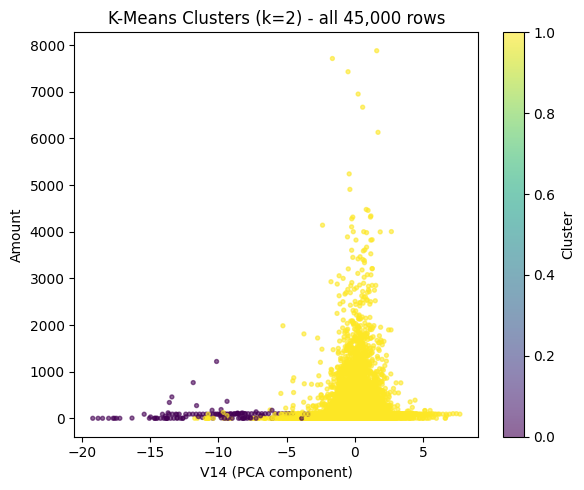

In [6]:
plt.figure(figsize=(6, 5))
scatter = plt.scatter(df["V14"].values, df["Amount"].values,
                       c=df["cluster"].values, cmap="viridis", s=8, alpha=0.6)
plt.xlabel("V14 (PCA component)")
plt.ylabel("Amount")
plt.title(f"K-Means Clusters (k={best_k}) - all 45,000 rows")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


### What Does the Picture Answer?

This time the story is the opposite of the full-dataset version. The two clusters separate almost entirely along the **horizontal (`V14`) axis**, not the vertical (`Amount`) axis. The vast majority of points form one dense mass hovering near `V14` ≈ 0, spanning the full range of `Amount` values. A small, visually distinct handful of points sits far out to the left, at strongly negative `V14` values (down around -8 to -11) — and those points span a similar `Amount` range to everything else, not the high-value outliers.

So `Amount` isn't driving this split at all — the two clusters have very similar average amounts ($82.84 vs $91.06). What *is* driving it is a small group of transactions with extreme values on several PCA components at once (`V14` most visibly here, but `V17`, `V3`, `V7`, `V12`, and `V10` separate the two clusters by even more in the full 29-dimensional scaled space). K-Means picked out a tiny population of statistically extreme transactions rather than splitting the data by size.


## Step 5 — The Question We've Been Building Toward: Does Any of This Line Up With Fraud?


In [7]:
print("Cluster sizes:")
print(df["cluster"].value_counts())

print("Mean Amount per cluster:")
print(df.groupby("cluster")["Amount"].mean().round(2))

print("Fraud rate per cluster (Class used only for interpretation):")
fraud_rate = df.groupby("cluster")["Class"].mean() * 100
print(fraud_rate.round(3).astype(str) + " %")


Cluster sizes:
cluster
1    44878
0      122
Name: count, dtype: int64
Mean Amount per cluster:
cluster
0    82.84
1    91.06
Name: Amount, dtype: float64
Fraud rate per cluster (Class used only for interpretation):
cluster
0    70.492 %
1     0.123 %
Name: Class, dtype: str


### The Answer

**Cluster 1 — The everyday mass (44,878 transactions, ~99.7% of the data).** Average amount is $91.06. This is ordinary, routine transaction behavior across every price point — small purchases and large ones alike, all sitting close to the center of the scaled feature space.

**Cluster 0 — A small, statistically extreme group (122 transactions, ~0.27% of the data).** Average amount is $82.84 — nearly identical to Cluster 1's — but these 122 transactions sit far out on several PCA components at once, most visibly `V14` (mean of -10.58, versus 0.22 for Cluster 1). This is a tight, unusual pocket of transaction behavior, not a size-based split.

**Bringing `Class` back in, only now, for a reality check:** this time the result is striking. Cluster 0 — the tiny, statistically extreme group — has a fraud rate of **70.5%**, while Cluster 1 has a fraud rate of just **0.123%**, close to what you'd expect from a normal, non-fraud transaction. Out of 141 fraudulent transactions in this dataset, a large share of them landed in a cluster that makes up barely a quarter of one percent of the data.

**So, back to the opening question — did the algorithm find something meaningful this time?** Yes, and unlike the full 284,807-row version of this lab, the structure K-Means found here lines up strongly with fraud. That's a genuinely different outcome from before — worth being honest about why. This 45,000-row file isn't a plain random slice of the full dataset: it keeps proportionally more fraud cases (0.31% here versus 0.17% in the full file) and, more importantly, this smaller scale let the handful of most extreme, PCA-anomalous transactions stand out as their own tight cluster instead of getting diluted into a mass of 284,807 points. That's a useful lesson in itself: unsupervised structure isn't fixed — how much of it aligns with a business question like fraud can shift with the composition and scale of the data you feed it, not just the algorithm. On the full dataset, K-Means found "transaction size." On this one, it found something closer to "statistical outlier" — and this time, that happened to be a strong proxy for fraud.
